In [1]:
!pip install kaggle==1.5.16

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.6/83.6 kB 8.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for kaggle: filename=kaggle-1.5.16-py3-none-any.whl size=110682 sha256=a1d75242baf7480e43c4b30a730cfe920a0cf9e9675746f266e9601934142e53
  Stored in directory: /root/.cache/pip/wheels/6a/2e/62/475f9443c6f7f73b3beb46e121e2d30f1fb77af8bc7ba7edd6
Successfully built kaggle
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [2]:
! chmod 600 .kaggle/kaggle.json

chmod: cannot access '.kaggle/kaggle.json': No such file or directory


In [3]:
! kaggle competitions download Walmart-Recruiting-Store-Sales-Forecasting

 74% 2.00M/2.70M [00:01<00:00, 2.07MB/s]
100% 2.70M/2.70M [00:01<00:00, 2.30MB/s]


In [4]:
! unzip Walmart-Recruiting-Store-Sales-Forecasting.zip

Archive:  Walmart-Recruiting-Store-Sales-Forecasting.zip
  inflating: features.csv.zip        
  inflating: sampleSubmission.csv.zip  
  inflating: stores.csv              
  inflating: test.csv.zip            
  inflating: train.csv.zip           


In [5]:
! unzip features.csv.zip
! unzip test.csv.zip
! unzip train.csv.zip

Archive:  features.csv.zip
  inflating: features.csv            
Archive:  test.csv.zip
  inflating: test.csv                
Archive:  train.csv.zip
  inflating: train.csv               


# DLinear — Walmart Store Sales Forecasting

In [6]:
!pip install "numpy<2" "torchvision==0.17.0" "torch==2.2.0" "neuralforecast==1.7.4" optuna mlflow dagshub wandb -q --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.2/94.2 kB 9.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 12.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, os
import wandb
import mlflow
import mlflow.pyfunc

from neuralforecast import NeuralForecast
from neuralforecast.models import DLinear
from neuralforecast.auto import AutoDLinear
from neuralforecast.losses.pytorch import MAE
from ray import tune

WANDB_ENTITY  = 'ikvas22-free-university-of-tbilisi'
WANDB_PROJECT = 'Walmart Weekly Sales Prediction'
WANDB_GROUP   = 'DLinear'

MLFLOW_EXPERIMENT = 'DLinear_Training'
MLFLOW_MODEL_NAME = 'dlinear_walmart_best'

TRAIN_PATH    = 'train.csv'
FEATURES_PATH = 'features.csv'
STORES_PATH   = 'stores.csv'

H          = 4
INPUT_SIZE = 52
N_TRIALS   = 5
VAL_START  = '2012-04-01'

wandb.login()

print('Setup OK')

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.0
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: ikvas22 (ikvas22-free-university-of-tbilisi) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Setup OK


## 1. Pre-processing

In [2]:
run = wandb.init(
    entity   = WANDB_ENTITY,
    project  = WANDB_PROJECT,
    group    = WANDB_GROUP,
    job_type = 'preprocessing',
    name     = 'DLinear_Preprocessing_More_Trials_And_HP',
)

train_raw    = pd.read_csv(TRAIN_PATH,    parse_dates=['Date'])
features_raw = pd.read_csv(FEATURES_PATH, parse_dates=['Date'])
stores_raw   = pd.read_csv(STORES_PATH)

df = (
    train_raw
    .merge(features_raw, on=['Store', 'Date', 'IsHoliday'], how='left')
    .merge(stores_raw,   on=['Store'],                       how='left')
)

wandb.log({
    'raw_rows' : df.shape[0],
    'raw_cols' : df.shape[1],
    'stores'   : df['Store'].nunique(),
    'depts'    : df['Dept'].nunique(),
    'date_min' : str(df['Date'].min().date()),
    'date_max' : str(df['Date'].max().date()),
})

null_pct = df.isnull().mean().mul(100).round(2)
null_df  = null_pct[null_pct > 0].reset_index()
null_df.columns = ['column', 'null_pct']
wandb.log({'null_percentages': wandb.Table(dataframe=null_df)})
print('Nulls (%):')
print(null_df.to_string(index=False))

# DLinear only needs the raw sales series — no tabular features
df['unique_id'] = df['Store'].astype(str) + '_' + df['Dept'].astype(str)
df_nf = (
    df[['unique_id', 'Date', 'Weekly_Sales', 'IsHoliday']]
    .rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
    .sort_values(['unique_id', 'ds'])
    .reset_index(drop=True)
)

min_len    = INPUT_SIZE + H
series_len = df_nf.groupby('unique_id')['ds'].count()
valid_ids  = series_len[series_len >= min_len].index
dropped    = series_len[series_len < min_len].index.tolist()
df_nf      = df_nf[df_nf['unique_id'].isin(valid_ids)].reset_index(drop=True)

wandb.log({
    'total_series'   : len(series_len),
    'valid_series'   : len(valid_ids),
    'dropped_series' : len(dropped),
    'dropped_ids'    : dropped,
    'min_series_len' : int(series_len[valid_ids].min()),
    'max_series_len' : int(series_len[valid_ids].max()),
})

print(f'\nValid series : {len(valid_ids)}')
print(f'Dropped      : {len(dropped)} (shorter than {min_len} weeks)')

df_train = df_nf[df_nf['ds'] <  VAL_START].copy()
df_val   = df_nf[df_nf['ds'] >= VAL_START].copy()

wandb.log({
    'train_rows'     : len(df_train),
    'val_rows'       : len(df_val),
    'train_date_min' : str(df_train['ds'].min().date()),
    'train_date_max' : str(df_train['ds'].max().date()),
    'val_date_min'   : str(df_val['ds'].min().date()),
    'val_date_max'   : str(df_val['ds'].max().date()),
    'val_start'      : VAL_START,
    'horizon_weeks'  : H,
    'lookback_weeks' : INPUT_SIZE,
})

print(f'Train : {df_train["ds"].min().date()} → {df_train["ds"].max().date()}  ({len(df_train):,} rows)')
print(f'Val   : {df_val["ds"].min().date()} → {df_val["ds"].max().date()}  ({len(df_val):,} rows)')

wandb.finish()

Nulls (%):
   column  null_pct
MarkDown1     64.26
MarkDown2     73.61
MarkDown3     67.48
MarkDown4     67.98
MarkDown5     64.08

Valid series : 2983
Dropped      : 348 (shorter than 56 weeks)
Train : 2010-02-05 → 2012-03-30  (328,806 rows)
Val   : 2012-04-06 → 2012-10-26  (87,383 rows)


depts,▁
dropped_series,▁
horizon_weeks,▁
lookback_weeks,▁
max_series_len,▁
min_series_len,▁
raw_cols,▁
raw_rows,▁
stores,▁
total_series,▁
+3,...


## 2. Training

In [3]:
def wmae(y_true: np.ndarray, y_pred: np.ndarray, is_holiday: np.ndarray) -> float:
    weights = np.where(is_holiday, 5.0, 1.0)
    return float(np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights))


def evaluate(nf: NeuralForecast, pred_col: str) -> tuple:
    preds   = nf.predict()
    eval_df = df_val.merge(
        preds.rename(columns={pred_col: 'y_pred'}),
        on=['unique_id', 'ds'], how='inner'
    )
    score_wmae = wmae(eval_df['y'].values, eval_df['y_pred'].values, eval_df['IsHoliday'].values)
    score_mae  = float(np.mean(np.abs(eval_df['y'].values - eval_df['y_pred'].values)))
    return score_wmae, score_mae, eval_df

df_full = pd.concat([df_train, df_val]).sort_values(['unique_id', 'ds']).reset_index(drop=True)

# Rolling windows covering the validation period (~28 weeks / 4 = 7 windows)
N_WINDOWS = 7

def evaluate_cv(nf: NeuralForecast, model_col: str) -> tuple:
    """
    Rolling-window evaluation over the whole validation period.
    Includes holiday weeks so WMAE weighting is meaningful.
    """
    cv_df = nf.cross_validation(
        df        = df_full[['unique_id', 'ds', 'y']],
        n_windows = N_WINDOWS,
        step_size = H,
    )
    cv_df = cv_df.reset_index() if 'unique_id' not in cv_df.columns else cv_df

    eval_df = cv_df.merge(
        df_full[['unique_id', 'ds', 'IsHoliday']],
        on=['unique_id', 'ds'], how='left'
    ).rename(columns={model_col: 'y_pred'})

    score_wmae = wmae(eval_df['y'].values, eval_df['y_pred'].values, eval_df['IsHoliday'].values)
    score_mae  = float(np.mean(np.abs(eval_df['y'].values - eval_df['y_pred'].values)))
    return score_wmae, score_mae, eval_df

In [4]:
run_baseline = wandb.init(
    entity   = WANDB_ENTITY,
    project  = WANDB_PROJECT,
    group    = WANDB_GROUP,
    job_type = 'training',
    name     = 'DLinear_Baseline_More_Trials_And_HP',
    config   = {
        'input_size'        : INPUT_SIZE,
        'h'                 : H,
        'moving_avg_window' : 25,
        'max_steps'         : 500,
        'learning_rate'     : 1e-3,
        'batch_size'        : 32,
        'loss'              : 'MAE',
        'eval'              : f'rolling_cv_{N_WINDOWS}_windows',
    }
)

baseline_model = DLinear(
    h                     = H,
    input_size            = INPUT_SIZE,
    moving_avg_window     = 25,
    loss                  = MAE(),
    max_steps             = 500,
    learning_rate         = 1e-3,
    batch_size            = 32,
    val_check_steps       = 50,
    start_padding_enabled = True,
    logger                = True,
)

nf_baseline = NeuralForecast(models=[baseline_model], freq='W-FRI')
baseline_wmae, baseline_mae, eval_baseline = evaluate_cv(nf_baseline, 'DLinear')

wandb.log({
    'val_wmae' : baseline_wmae,
    'val_mae'  : baseline_mae,
})

print(f'Baseline WMAE : {baseline_wmae:,.2f}')
print(f'Baseline MAE  : {baseline_mae:,.2f}')

wandb.finish()

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ decomp        │ SeriesDecomp  │      0 │ train │     0 │
│ 4 │ linear_trend  │ Linear        │    212 │ train │     0 │
│ 5 │ linear_season │ Linear        │    212 │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 424                                                                                              
Non-trainable params: 0                                                                                            
Total params: 424                                                                                                  
Total estimated model params size (MB): 0.002                                                                      
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

Baseline WMAE : 1,763.79
Baseline MAE  : 1,764.59


val_mae,▁
val_wmae,▁
val_mae,1764.59424
val_wmae,1763.78791


INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



── Trial 1/50: {'input_size': 52, 'moving_avg_window': 25, 'learning_rate': 0.001, 'batch_size': 32}


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ decomp        │ SeriesDecomp  │      0 │ train │     0 │
│ 4 │ linear_trend  │ Linear        │    212 │ train │     0 │
│ 5 │ linear_season │ Linear        │    212 │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 424                                                                                              
Non-trainable params: 0                                                                                            
Total params: 424                                                                                                  
Total estimated model params size (MB): 0.002                                                                      
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


════════════════════════════════════
Best WMAE     : 1,712.12
Baseline WMAE : 1,763.79
Improvement   : 51.66
Best params   : {'input_size': 52, 'moving_avg_window': 13, 'learning_rate': 0.001, 'batch_size': 64}


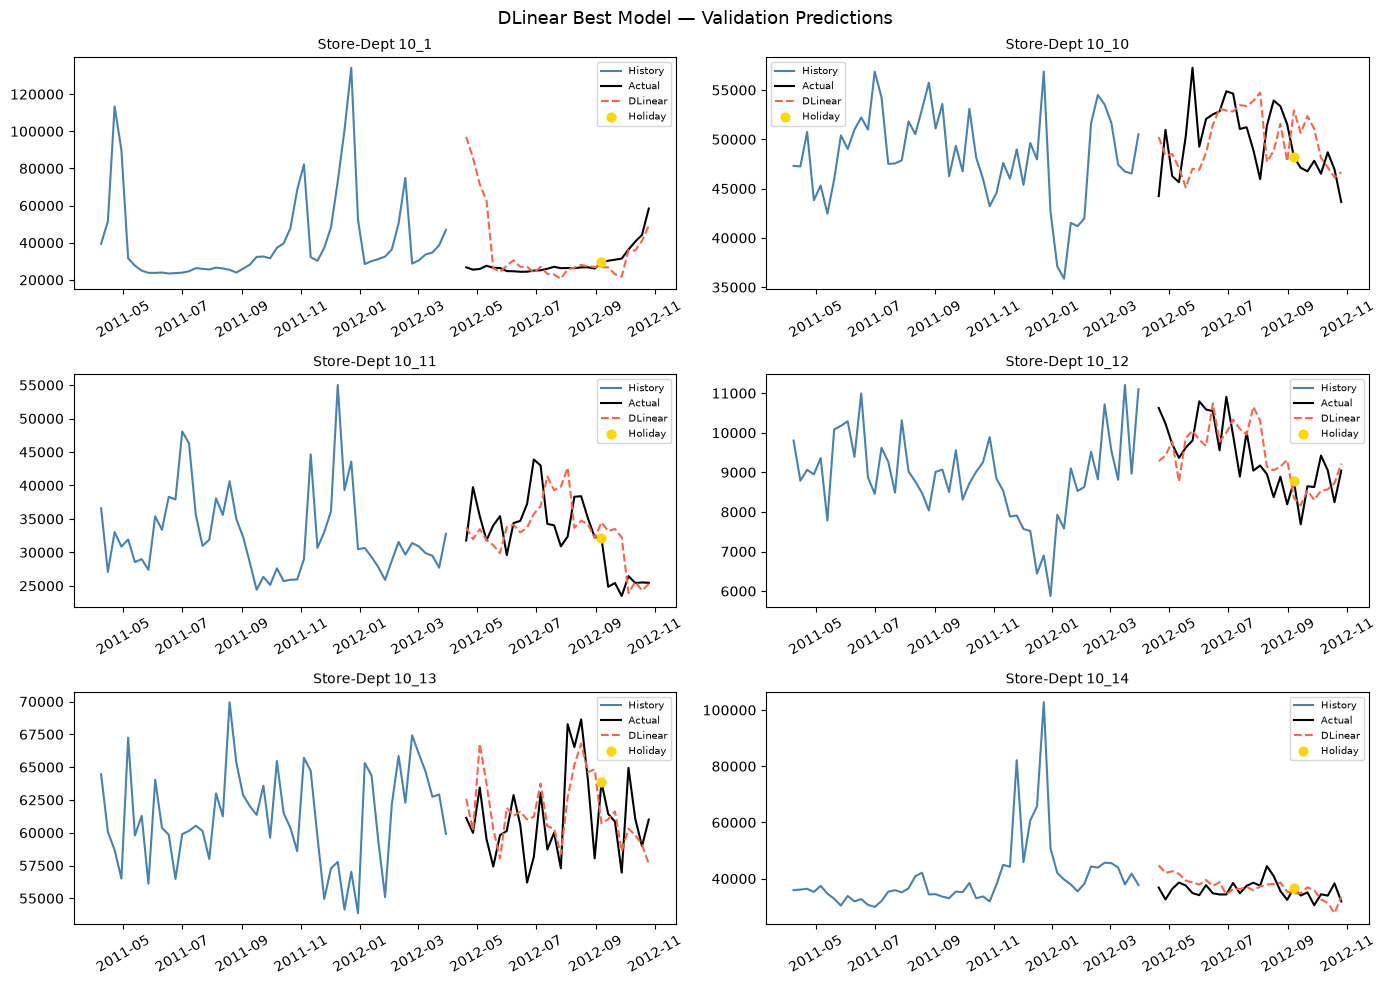

baseline_wmae,▁
best_val_mae,▁
best_val_wmae,▁
trials_completed,▁
wmae_improvement,▁
baseline_wmae,1763.78791
best_params,"{'input_size': 52, '..."
best_val_mae,1714.34124
best_val_wmae,1712.12499
trials_completed,50
wmae_improvement,51.66292


In [5]:
# ── Manual hyperparameter search (random search) ───────────────
N_TRIALS = 50   # DLinear is fast — can afford more trials

run_search = wandb.init(
    entity   = WANDB_ENTITY,
    project  = WANDB_PROJECT,
    group    = WANDB_GROUP,
    job_type = 'training',
    name     = 'DLinear_HPSearch_More_Trials_And_HP',
    config   = {
        'n_trials'    : N_TRIALS,
        'h'           : H,
        'search_type' : 'random',
        'search_space': {
            'input_size'        : [13, 26, 52, 104],
            'moving_avg_window' : [4, 8, 13, 25, 52],
            'learning_rate'     : [1e-4, 5e-4, 1e-3, 5e-5],
            'batch_size'        : [16, 32, 64, 128],
        }
    }
)

from itertools import product
import random
random.seed(42)

search_space = {
    'input_size'        : [26, 52, 104],
    'moving_avg_window' : [5, 9, 13, 25, 53],
    'learning_rate'     : [1e-4, 5e-4, 1e-3],
    'batch_size'        : [16, 32, 64],
}

all_combos = list(product(*search_space.values()))
sampled    = random.sample(all_combos, min(N_TRIALS, len(all_combos)))
keys       = list(search_space.keys())

# Include the baseline config as trial 0 — guarantees search >= baseline
baseline_combo = (INPUT_SIZE, 25, 1e-3, 32)
if baseline_combo not in sampled:
    sampled = [baseline_combo] + sampled[:-1]

best_wmae     = float('inf')
best_mae      = None
best_params   = None
nf_auto       = None
trial_results = []

for i, combo in enumerate(sampled):
    params = dict(zip(keys, combo))
    print(f'\n── Trial {i+1}/{len(sampled)}: {params}')

    model = DLinear(
        h                     = H,
        input_size            = params['input_size'],
        moving_avg_window     = params['moving_avg_window'],
        loss                  = MAE(),
        max_steps             = 500,
        learning_rate         = params['learning_rate'],
        batch_size            = params['batch_size'],
        val_check_steps       = 50,
        start_padding_enabled = True,
    )

    nf = NeuralForecast(models=[model], freq='W-FRI')
    trial_wmae, trial_mae, _ = evaluate_cv(nf, 'DLinear')

    print(f'   WMAE: {trial_wmae:,.2f}   MAE: {trial_mae:,.2f}')
    trial_results.append({
        'trial'             : i + 1,
        'input_size'        : params['input_size'],
        'moving_avg_window' : params['moving_avg_window'],
        'learning_rate'     : params['learning_rate'],
        'batch_size'        : params['batch_size'],
        'wmae'              : trial_wmae,
        'mae'               : trial_mae,
    })

    if trial_wmae < best_wmae:
        best_wmae   = trial_wmae
        best_mae    = trial_mae
        best_params = params
        nf_auto     = nf

trials_df = pd.DataFrame(trial_results)
_, _, eval_best = evaluate_cv(nf_auto, 'DLinear')

wandb.log({
    'best_val_wmae'    : best_wmae,
    'best_val_mae'     : best_mae,
    'baseline_wmae'    : baseline_wmae,
    'wmae_improvement' : baseline_wmae - best_wmae,
    'best_params'      : str(best_params),
    'trials_completed' : len(sampled),
    'all_trials'       : wandb.Table(dataframe=trials_df),
})

print(f'\n════════════════════════════════════')
print(f'Best WMAE     : {best_wmae:,.2f}')
print(f'Baseline WMAE : {baseline_wmae:,.2f}')
print(f'Improvement   : {baseline_wmae - best_wmae:,.2f}')
print(f'Best params   : {best_params}')

# Prediction plots
sample_ids = eval_best['unique_id'].unique()[:6]
fig, axes  = plt.subplots(3, 2, figsize=(14, 10))
axes       = axes.flatten()

for ax, uid in zip(axes, sample_ids):
    history = df_train[df_train['unique_id'] == uid].tail(52)
    actual  = eval_best[eval_best['unique_id'] == uid]
    ax.plot(history['ds'], history['y'],     label='History', color='steelblue')
    ax.plot(actual['ds'],  actual['y'],      label='Actual',  color='black')
    ax.plot(actual['ds'],  actual['y_pred'], label='DLinear', color='tomato', linestyle='--')
    hol = actual[actual['IsHoliday'] == 1]
    ax.scatter(hol['ds'], hol['y'], color='gold', zorder=5, s=40, label='Holiday')
    ax.set_title(f'Store-Dept {uid}', fontsize=10)
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('DLinear Best Model — Validation Predictions', fontsize=13)
plt.tight_layout()
wandb.log({'prediction_plots': wandb.Image(fig)})
plt.show()

# Per-series WMAE
per_series = (
    eval_best
    .groupby('unique_id')
    .apply(lambda g: wmae(g['y'].values, g['y_pred'].values, g['IsHoliday'].values))
    .reset_index()
    .rename(columns={0: 'wmae'})
    .sort_values('wmae', ascending=False)
)
wandb.log({'per_series_wmae': wandb.Table(dataframe=per_series)})

wandb.finish()

## 3. Save Best Model to MLflow Registry

In [6]:
import dagshub
dagshub.init(repo_owner='ikvas22', repo_name='Walmart-Recruiting---Store-Sales-Forecasting', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=cb6a1847-d0c2-48f3-ad70-8ab4dba7329b&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=bbfaee49b2a2c9af00e5bc2ff85be76c6c394694834e1fde6ea985663120c729




Accessing as ikvas22

Initialized MLflow to track repo "ikvas22/Walmart-Recruiting---Store-Sales-Forecasting"

Repository ikvas22/Walmart-Recruiting---Store-Sales-Forecasting initialized!

In [7]:
mlflow.set_experiment(MLFLOW_EXPERIMENT)

2026/07/05 08:15:16 INFO mlflow.tracking.fluent: Experiment with name 'DLinear_Training' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/172cdc16ee2e41e185fdbd0174663fdf', creation_time=1783239316309, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1783239316309, lifecycle_stage='active', name='DLinear_Training', tags={}, trace_location=None, workspace='default'>

In [10]:
class DLinearWrapper(mlflow.pyfunc.PythonModel):

    def load_context(self, context):
        with open(context.artifacts['nf_model'], 'rb') as f:
            self.nf = pickle.load(f)

    def predict(self, context, model_input: pd.DataFrame) -> pd.DataFrame:
        """
        Accepts raw DataFrame with [Store, Dept, Date, Weekly_Sales].
        Returns [Store, Dept, Date, Weekly_Sales_pred].
        """
        df_in              = model_input.copy()
        df_in['Date']      = pd.to_datetime(df_in['Date'])
        df_in['unique_id'] = df_in['Store'].astype(str) + '_' + df_in['Dept'].astype(str)
        df_nf_in = (
            df_in
            .rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
            [['unique_id', 'ds', 'y']]
            .sort_values(['unique_id', 'ds'])
        )
        preds    = self.nf.predict(df=df_nf_in)
        preds    = preds.reset_index()
        pred_col = [c for c in preds.columns if c not in ['unique_id', 'ds']][0]
        preds    = preds.rename(columns={pred_col: 'Weekly_Sales_pred'})
        preds[['Store', 'Dept']] = preds['unique_id'].str.split('_', expand=True).astype(int)
        return preds[['Store', 'Dept', 'ds', 'Weekly_Sales_pred']].rename(columns={'ds': 'Date'})


os.makedirs('mlflow_artifacts', exist_ok=True)
model_path = 'mlflow_artifacts/nf_auto_dlinear.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(nf_auto, f)

with mlflow.start_run(run_name='DLinear_Best_Model') as run:
    mlflow.log_params(best_params)
    mlflow.log_metrics({
        'val_wmae'         : best_wmae,
        'val_mae'          : best_mae,
        'baseline_wmae'    : baseline_wmae,
        'wmae_improvement' : baseline_wmae - best_wmae,
        'n_trials'         : N_TRIALS,
    })
    mlflow.pyfunc.log_model(
        artifact_path         = 'dlinear_model',
        python_model          = DLinearWrapper(),
        artifacts             = {'nf_model': model_path},
        registered_model_name = MLFLOW_MODEL_NAME,
    )
    print(f'Registered: {MLFLOW_MODEL_NAME}')
    print(f'Run ID    : {run.info.run_id}')
    print(f'Best WMAE : {best_wmae:,.2f}')

2026/07/05 08:18:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/05 08:18:19 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/07/05 08:18:19 WARNING mlflow.pyfunc: Failed to infer model signature: Type hint <input: <class 'pandas.core.frame.DataFrame'>, output: <class 'pandas.core.frame.DataFrame'>> cannot be used to infer model signature and input example is not provided, model signature cannot be inferred.


Registered model 'dlinear_walmart_best' already exists. Creating a new version of this model...
2026/07/05 08:18:38 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: dlinear_walmart_best, version 2
Created version '2' of model 'dlinear_walmart_best'.


Registered: dlinear_walmart_best
Run ID    : a7644ecabc4c476c8efa411e41fc7425
Best WMAE : 1,712.12
🏃 View run DLinear_Best_Model at: https://dagshub.com/ikvas22/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/1/runs/a7644ecabc4c476c8efa411e41fc7425
🧪 View experiment at: https://dagshub.com/ikvas22/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/1


In [11]:
loaded = mlflow.pyfunc.load_model(f'models:/{MLFLOW_MODEL_NAME}/latest')
sample = train_raw[train_raw['Store'] == 1][['Store', 'Dept', 'Date', 'Weekly_Sales']].head(100)
result = loaded.predict(sample)
print('Registry load OK')
print(result.head())

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

Registry load OK
   Store  Dept       Date  Weekly_Sales_pred
0      1     1 2012-01-06       24604.462891
1      1     1 2012-01-13       26735.884766
2      1     1 2012-01-20       32094.101562
3      1     1 2012-01-27       25849.480469
